In [1]:
df = spark.read.format("csv").option("header","true").load("Files/2019.csv")
# df now is a Spark DataFrame containing CSV data from "Files/2019.csv".
display(df)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 3, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a3f6291f-05c8-47d5-83c0-307a66bb230f)

In [4]:
df = spark.read.format("csv").option("header","true").load("Files/2019.csv")

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 6, Finished, Available, Finished, False)

In [5]:
display(df)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 7, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 4e7d549d-c97a-4c50-8fda-cd74768d8da5)

In [9]:
from pyspark.sql.types import *

orderSchema = StructType([
    StructField("OrderID", IntegerType()),
    StructField("CustomerID", StringType()),
    StructField("OrderDate", DateType()),
    StructField("Product", StringType()),
    StructField("Quantity", IntegerType()),
    StructField("Price", FloatType())
])

df = spark.read.format("csv").option("header","true").schema(orderSchema).load("Files/2019.csv")

display(df)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 11, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 32fa8ce7-270d-4bbc-b3b8-fa841867552d)

In [10]:
from pyspark.sql.types import *

orderSchema = StructType([
    StructField("OrderID", IntegerType()),
    StructField("CustomerID", StringType()),
    StructField("OrderDate", DateType()),
    StructField("Product", StringType()),
    StructField("Quantity", IntegerType()),
    StructField("Price", FloatType())
])

df = spark.read.format("csv").option("header","true").schema(orderSchema).load("Files/*.csv")

display(df)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 12, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, cf4dabc8-ce52-4abd-9f80-35c73bf51cd2)

In [11]:
customers = df['CustomerID', 'Product']

print(customers.count())
print(customers.distinct().count())

display(customers.distinct())

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 13, Finished, Available, Finished, False)

15
12


SynapseWidget(Synapse.DataFrame, 3eb711c3-9032-4f33-ae6e-8de2b6b2e6ac)

In [12]:
customers = df.select("CustomerID", "Product").where(df['Quantity']== 1)
print(customers.count())
print(customers.distinct().count())

display(customers.distinct())

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 14, Finished, Available, Finished, False)

3
3


SynapseWidget(Synapse.DataFrame, 4e4c8216-7222-4ee3-b73f-4c19ca4d34eb)

In [13]:
ProductSales = df.select("Product", "Quantity").groupBy("Product").sum()

display(ProductSales)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 15, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, e2db782c-9fa7-4927-af77-66c616bf7c7e)

In [14]:
from pyspark.sql.functions import *
yearlySales = df.select(year(col("orderDate")).alias("Year")).groupBy("Year").count().orderBy("Year")

display(yearlySales)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 16, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, f7d4fc0d-5be1-43ef-933d-df3ac4db0aee)

In [15]:
# Create Year and Months columns
transformed_df = df.withColumn("Year", year(col("OrderDate"))).withColumn("Month", month(col("OrderDate")))

display(transformed_df)


StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 17, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 5fe7ad83-bfe6-44d0-8ca1-313321e770b3)

In [16]:
transformed_df.write.mode("overwrite").parquet("Files/transformed_data/orders")

print("transformed data saved")


StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 18, Finished, Available, Finished, False)

transformed data saved


In [17]:
order_df = spark.read.format("parquet").load("Files/transformed_data/orders/*.parquet")
display(order_df)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 19, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 42768f8c-2fa1-48c5-ad5c-1bf24e90d510)

In [18]:
order_df.write.partitionBy("Year", "Month").mode("overwrite").parquet("Files/partitioned_data")

print("Transfomed Saved")

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 20, Finished, Available, Finished, False)

Transfomed Saved


In [20]:
orders_2020_df = spark.read.format("parquet").load("Files/partitioned_data/Year=2020/Month=*")
display(orders_2020_df)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 22, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 6b417ff0-1e95-40c4-91c4-4deb8777e164)

In [21]:
# create table from df

df.write.format("delta").saveAsTable("salesorders")

spark.sql("DESCRIBE EXTENDED salesorders").show(truncate=False)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 23, Finished, Available, Finished, False)

+----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------+
|col_name                    |data_type                                                                                                                                |comment|
+----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------+
|OrderID                     |int                                                                                                                                      |NULL   |
|CustomerID                  |string                                                                                                                                   |NULL   |
|OrderDate                   |date                                                                                 

In [22]:
df = spark.sql("SELECT * FROM Data.dbo.salesorders LIMIT 1000")
display(df)

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 24, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, d0888d8b-1ba4-4e86-b0ce-f69842bc4b31)

In [23]:
%%sql
SELECT YEAR(OrderDate) as OrderYear,
        SUM(Price * Quantity) AS GrossRevenue

FROM Salesorders
GROUP BY YEAR(OrderDate)
ORDER BY OrderYear;

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 25, Finished, Available, Finished, False)

<Spark SQL result set with 3 rows and 2 fields>

In [24]:
%%sql
SELECT * FROM salesorders

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 26, Finished, Available, Finished, False)

<Spark SQL result set with 15 rows and 6 fields>

In [25]:
## Create chart
sqlQuery = "SELECT CAST(YEAR(OrderDate) AS CHAR(4)) AS OrderYear, \
               SUM(Price * Quantity) As GrossRevenue \
               FROM Salesorders \
               GROUP BY YEAR(OrderDate) \
               ORDER BY OrderYear "
df_spark = spark.sql(sqlQuery)
df_spark.show()

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 27, Finished, Available, Finished, False)

+---------+------------+
|OrderYear|GrossRevenue|
+---------+------------+
|     2019|       297.5|
|     2020|       265.5|
|     2021|       289.5|
+---------+------------+



StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 28, Finished, Available, Finished, False)

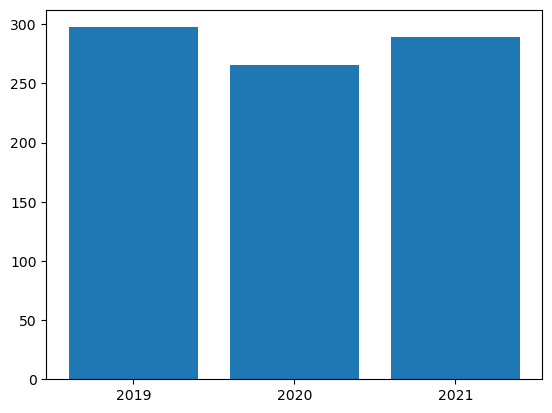

In [26]:
## Create chart using matplot lib
from matplotlib import pyplot as plt

df_sales = df_spark.toPandas()
plt.bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'])

plt.show()

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 30, Finished, Available, Finished, False)

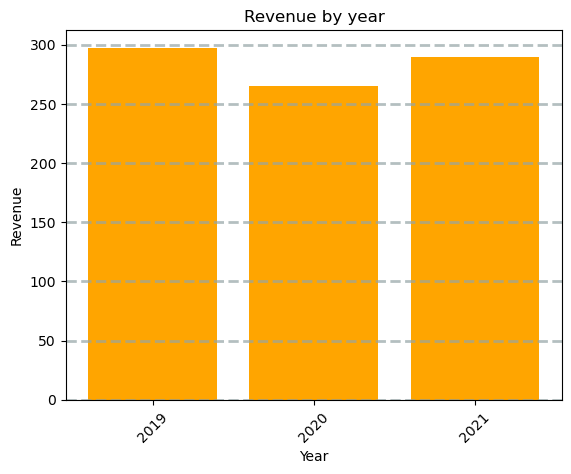

In [28]:
from matplotlib import pyplot as plt

plt.clf()

plt.bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')

plt.title('Revenue by year')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.grid(color='#95a5a6', linestyle='--', linewidth=2, axis='y', alpha=0.7)
plt.xticks(rotation=45)

plt.show()

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 33, Finished, Available, Finished, False)

<Figure size 640x480 with 0 Axes>

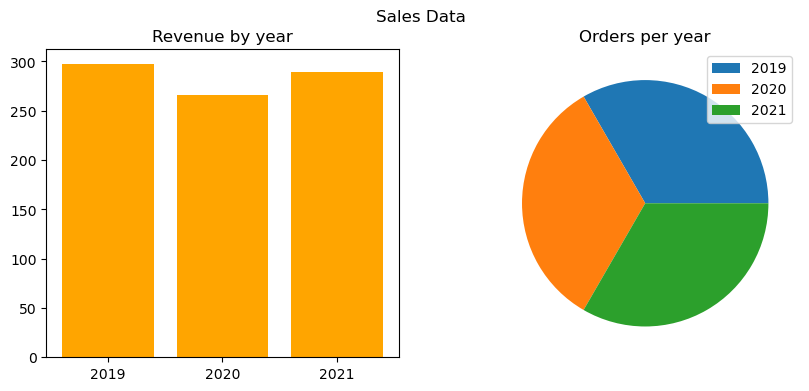

In [31]:
from matplotlib import pyplot as plt

plt.clf()

fig , ax = plt.subplots(1, 2, figsize = (10,4))

ax[0].bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')
ax[0].set_title('Revenue by year')

yearly_counts = df_sales['OrderYear'].value_counts()
ax[1].pie(yearly_counts)
ax[1].set_title('Orders per year')
ax[1].legend(yearly_counts.keys().tolist())

fig.suptitle('Sales Data')
plt.show()

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 34, Finished, Available, Finished, False)

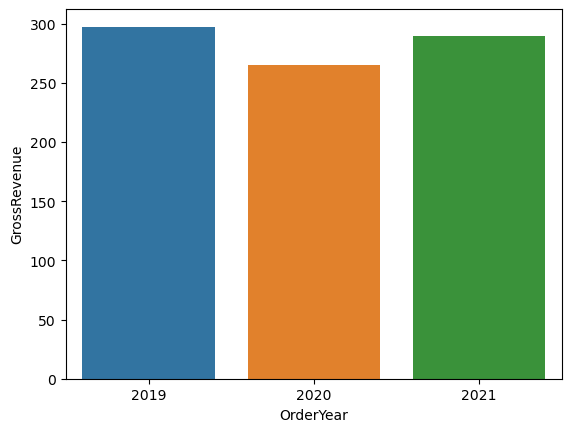

In [32]:
import seaborn as sns 

plt.clf()

ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 35, Finished, Available, Finished, False)

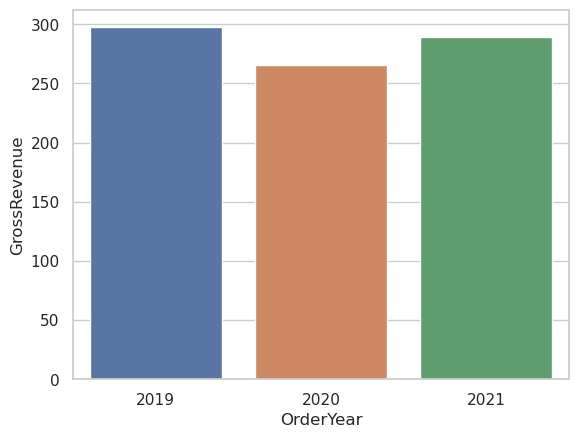

In [33]:

plt.clf()

sns.set_theme(style="whitegrid")

ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()

StatementMeta(, fc92ac94-94ef-40c0-9bcd-a789b3d7823f, 36, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


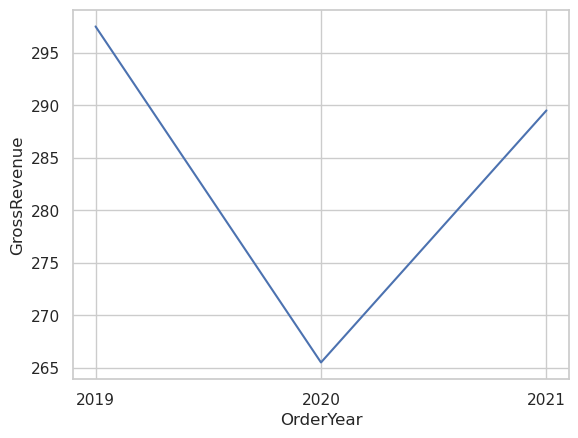

In [34]:
plt.clf()

ax = sns.lineplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()